# Control Variates for Neural Posterior Estimation

## Context

In `working_12_IS` we investigated **importance sampling** (IS) as a variance reduction technique for training neural posterior estimators on the AR(1) model $x_t = \rho\, x_{t-1} + \sigma\,\varepsilon_t$. IS changes *where* we sample parameters during training, but the per-sample loss estimates can still have high variance due to simulation noise and weight variability.

This notebook investigates **control variates** (CV) -- a complementary variance reduction technique -- and a closely related idea, **input augmentation** with sufficient statistics.

## What Are Control Variates?

Control variates exploit correlation. If we want to estimate $\mu = \mathbb{E}[f(X)]$ via Monte Carlo, and we know a function $g(X)$ with known mean $\mu_g = \mathbb{E}[g(X)]$ that is **correlated** with $f$, we can form the **CV-adjusted estimator**:

$$\hat\mu_{\text{CV}} = \frac{1}{N}\sum_{i=1}^N \bigl[f(X_i) - c\,(g(X_i) - \mu_g)\bigr]$$

**Key properties:**
- **Unbiased** for any coefficient $c$, since $\mathbb{E}[g - \mu_g] = 0$
- **Optimal coefficient:** $c^* = \mathrm{Cov}(f, g) / \mathrm{Var}(g)$
- **Variance reduction:** $\mathrm{Var}(\hat\mu_{\text{CV}}) / \mathrm{Var}(\hat\mu) = 1 - \rho^2_{f,g}$

where $\rho_{f,g}$ is the Pearson correlation between $f$ and $g$. The higher the correlation, the greater the variance reduction.

## Application to Neural Posterior Estimation

For our AR(1) problem, the **OLS (Ordinary Least Squares) estimator** provides a natural control variate:

$$\hat\rho_{\text{OLS}} = \frac{\sum_{t=1}^T x_t\, x_{t-1}}{\sum_{t=1}^T x_{t-1}^2}, \qquad \hat\sigma_{\text{OLS}} = \sqrt{\frac{1}{T-1}\sum_{t=1}^T (x_t - \hat\rho_{\text{OLS}}\, x_{t-1})^2}$$

We use OLS in two ways:

1. **CV for evaluation:** Use $\|\hat\theta_{\text{OLS}} - \theta\|^2$ as a control variate when estimating $\mathbb{E}[\|\hat\theta_{\text{NN}} - \theta\|^2]$, yielding tighter confidence intervals on test MSE.

2. **Input augmentation:** Feed $(\hat\rho_{\text{OLS}}, \hat\sigma_{\text{OLS}})$ as additional features to the neural network, so it can refine the classical estimate rather than learning from scratch.

## Experimental Protocol

| Parameter | Value |
|-----------|-------|
| Methods | Standard GRU vs Augmented GRU (with OLS features) |
| Independent runs per condition | $R = 3$ |
| Alpha values (IS) | $\{1.0,\; 0.5,\; 0.3,\; 0.1\}$ |
| Total models trained | $2 \times 4 \times 3 = 24$ |
| Shared test set | $N = 10{,}000$ (uniform, fixed seed) |
| Training | 128 epochs, 128 batches/epoch, batch\_size = 128 |

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import ttest_rel, wilcoxon
import torch
import torch.nn as nn
from tqdm import tqdm
import time

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Using device: cpu


In [2]:
# Configuration
A = 5.0
T = 64

ALPHA_VALUES = [1.0, 0.5, 0.3, 0.1]
METHODS = ['standard', 'augmented']

N_EPOCHS = 64
N_BATCHES_PER_EPOCH = 64
TRAINING_BATCH_SIZE = 64

N_EVAL = 10_000
R = 3              # runs per (method, alpha) pair
BASE_SEED = 42
BETA_SIGMA = 1

print("Configuration loaded")
print(f"Total models to train: {len(METHODS)} methods x {len(ALPHA_VALUES)} alphas x {R} runs = {len(METHODS)*len(ALPHA_VALUES)*R}")

Configuration loaded
Total models to train: 2 methods x 4 alphas x 3 runs = 24


In [3]:
# ── Reproducibility ──────────────────────────────────────────────────
def set_seed(seed):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

# ── Proposal sampling & IS weights ──────────────────────────────────
def sample_from_proposal(batch_size, alpha_rho, alpha_sigma, beta_sigma, A, device='cpu'):
    rho_tilde = np.random.beta(alpha_rho, alpha_rho, size=batch_size)
    sigma_tilde = np.random.beta(alpha_sigma, beta_sigma, size=batch_size)
    rho = 2 * rho_tilde - 1
    sigma = A * sigma_tilde
    rho = torch.tensor(rho, dtype=torch.float32, device=device)
    sigma = torch.tensor(sigma, dtype=torch.float32, device=device)
    return rho, sigma

def compute_importance_weights(rho, sigma, alpha_rho, alpha_sigma, beta_sigma, A):
    if torch.is_tensor(rho):
        rho = rho.cpu().numpy()
        sigma = sigma.cpu().numpy()
    rho_tilde = (rho + 1) / 2
    sigma_tilde = sigma / A
    q_rho = stats.beta.pdf(rho_tilde, alpha_rho, alpha_rho) / 2
    q_sigma = stats.beta.pdf(sigma_tilde, alpha_sigma, beta_sigma) / A
    q_theta = q_rho * q_sigma
    p_theta = 1.0 / (2 * A)
    return p_theta / q_theta

# ── AR(1) simulator ─────────────────────────────────────────────────
def simulate_ar1_batch(rho, sigma, T, batch_size, device='cpu'):
    eps = torch.randn(batch_size, T, device=device) * sigma[:, None]
    rho_safe = torch.clamp(rho, -0.9999, 0.9999)
    x0 = torch.randn(batch_size, device=device) * sigma / torch.sqrt(1 - rho_safe**2 + 1e-8)
    x = torch.zeros(batch_size, T, device=device)
    x[:, 0] = rho * x0 + eps[:, 0]
    for t in range(1, T):
        x[:, t] = rho * x[:, t-1] + eps[:, t]
    return x

# ── Gibbs sampler ───────────────────────────────────────────────────
def truncated_normal(mu, sigma, a=-1, b=1):
    while True:
        s = np.random.normal(mu, sigma)
        if a <= s <= b:
            return s

def truncated_gamma(shape, scale, a=1/A**2):
    while True:
        s = np.random.gamma(shape, scale)
        if s >= a:
            return s

def gibbs(x, n_iter=1000):
    T_len = len(x) - 1
    Q = np.sum(x[:-1]**2)
    rho_hat = np.sum(x[:-1] * x[1:]) / Q
    const = np.sum(x[1:]**2) - Q * rho_hat**2
    S = lambda rho: Q * (rho - rho_hat)**2 + const
    samples = np.zeros((n_iter, 2))
    for i in range(n_iter):
        lambda_ = truncated_gamma(T_len/2, 2/(S(rho_hat) + 1e-6))
        sig = 1/np.sqrt(lambda_)
        samples[i, 1] = sig
        samples[i, 0] = truncated_normal(rho_hat, sig/np.sqrt(Q))
    return samples

# ── OLS estimator (control variate) ────────────────────────────────
def compute_ols_batch(x):
    """Compute OLS estimates of (rho, sigma) from batched AR(1) time series.

    Args:
        x: (batch, T) tensor of time series
    Returns:
        (batch, 2) tensor of [rho_hat, sigma_hat]
    """
    x_lag  = x[:, :-1]   # x_{t-1}, shape (batch, T-1)
    x_lead = x[:, 1:]    # x_t,     shape (batch, T-1)

    num = (x_lead * x_lag).sum(dim=1)
    den = (x_lag ** 2).sum(dim=1) + 1e-8
    rho_hat = (num / den).clamp(-1.0, 1.0)

    residuals = x_lead - rho_hat.unsqueeze(1) * x_lag
    sigma_hat = (residuals ** 2).mean(dim=1).clamp(min=1e-8).sqrt()

    return torch.stack([rho_hat, sigma_hat], dim=1)

# ── Standard GRU model ──────────────────────────────────────────────
class GRUPosteriorEstimator(nn.Module):
    def __init__(self, input_dim=1, hidden_dim=64, num_layers=2, mlp_hidden=128):
        super().__init__()
        self.gru = nn.GRU(input_size=input_dim, hidden_size=hidden_dim,
                          num_layers=num_layers, batch_first=True)
        self.mlp = nn.Sequential(
            nn.Linear(hidden_dim, mlp_hidden), nn.ReLU(),
            nn.Linear(mlp_hidden, mlp_hidden), nn.ReLU(),
            nn.Linear(mlp_hidden, 32), nn.ReLU(),
            nn.Linear(32, 2))

    def forward(self, x, ols_features=None):
        x = x.unsqueeze(-1)
        gru_out, _ = self.gru(x)
        pooled = gru_out.mean(dim=1)
        raw = self.mlp(pooled)
        rho = torch.tanh(raw[:, 0])
        sigma = torch.exp(raw[:, 1])
        return torch.stack([rho, sigma], dim=1)

# ── Augmented GRU model (with OLS features) ─────────────────────────
class AugmentedGRUPosteriorEstimator(nn.Module):
    """GRU with OLS sufficient statistics concatenated to the pooled hidden state."""
    def __init__(self, input_dim=1, hidden_dim=64, num_layers=2,
                 mlp_hidden=128, aug_dim=2):
        super().__init__()
        self.gru = nn.GRU(input_size=input_dim, hidden_size=hidden_dim,
                          num_layers=num_layers, batch_first=True)
        self.mlp = nn.Sequential(
            nn.Linear(hidden_dim + aug_dim, mlp_hidden), nn.ReLU(),
            nn.Linear(mlp_hidden, mlp_hidden), nn.ReLU(),
            nn.Linear(mlp_hidden, 32), nn.ReLU(),
            nn.Linear(32, 2))

    def forward(self, x, ols_features=None):
        x_in = x.unsqueeze(-1)
        gru_out, _ = self.gru(x_in)
        pooled = gru_out.mean(dim=1)
        if ols_features is not None:
            pooled = torch.cat([pooled, ols_features], dim=1)
        raw = self.mlp(pooled)
        rho = torch.tanh(raw[:, 0])
        sigma = torch.exp(raw[:, 1])
        return torch.stack([rho, sigma], dim=1)

print("All core functions loaded")

All core functions loaded


## B. Control Variates: Theory and Demonstration

### How it works

Suppose we estimate $\mu = \mathbb{E}[f(X)]$ with $\hat\mu = \frac{1}{N}\sum f(X_i)$. Now let $g(X)$ be a **control variate** with known mean $\mu_g$. Define:

$$\hat\mu_{\text{CV}} = \hat\mu - c\,(\bar g - \mu_g), \qquad \bar g = \tfrac{1}{N}\sum g(X_i)$$

The variance is:

$$\text{Var}(\hat\mu_{\text{CV}}) = \text{Var}(\hat\mu)\bigl[1 + c^2\,\text{Var}(g)/\text{Var}(f) - 2c\,\rho_{fg}\,\text{std}(g)/\text{std}(f)\bigr]$$

Minimising over $c$ gives $c^* = \text{Cov}(f,g)/\text{Var}(g)$ and the relative variance reduction is $1 - \rho_{fg}^2$.

For the OLS control variate, $\rho_{fg}$ is the correlation between the neural network's per-sample loss and the OLS per-sample loss. Since both estimators make similar errors (e.g., both struggle with high $|\rho|$), we expect high correlation and substantial variance reduction.

Below we demonstrate control variates on a simple example before applying them to our problem.

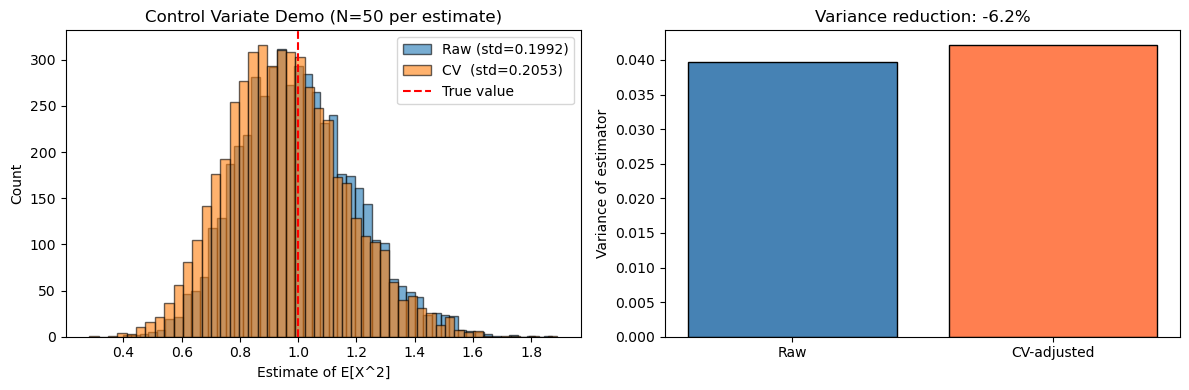

Variance reduction: -6.2%
Theoretical (rho^2 = 0 for symmetric dist): actual reduction comes from batch c* estimation


In [4]:
# Simple CV demonstration: estimate E[X^2] where X ~ N(0,1)
# True answer: 1.0
# Control variate: g(X) = X, with E[X] = 0
set_seed(42)

N_demo = 50
N_reps = 5000

raw_estimates = np.zeros(N_reps)
cv_estimates = np.zeros(N_reps)

for rep in range(N_reps):
    X = np.random.randn(N_demo)
    f = X**2             # want E[X^2] = 1
    g = X               # control variate, E[X] = 0

    raw_estimates[rep] = f.mean()

    # Optimal c from this batch
    c_star = np.cov(f, g)[0, 1] / (np.var(g) + 1e-12)
    cv_estimates[rep] = f.mean() - c_star * g.mean()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(raw_estimates, bins=50, alpha=0.6, label=f'Raw (std={raw_estimates.std():.4f})', edgecolor='black')
axes[0].hist(cv_estimates, bins=50, alpha=0.6, label=f'CV  (std={cv_estimates.std():.4f})', edgecolor='black')
axes[0].axvline(x=1.0, color='r', linestyle='--', label='True value')
axes[0].set_xlabel('Estimate of E[X^2]'); axes[0].set_ylabel('Count')
axes[0].set_title(f'Control Variate Demo (N={N_demo} per estimate)')
axes[0].legend()

reduction = 1 - cv_estimates.var() / raw_estimates.var()
axes[1].bar(['Raw', 'CV-adjusted'], [raw_estimates.var(), cv_estimates.var()],
            color=['steelblue', 'coral'], edgecolor='black')
axes[1].set_ylabel('Variance of estimator')
axes[1].set_title(f'Variance reduction: {reduction:.1%}')

plt.tight_layout(); plt.show()
print(f"Variance reduction: {reduction:.1%}")
print(f"Theoretical (rho^2 = 0 for symmetric dist): actual reduction comes from batch c* estimation")

## C. OLS Estimator for AR(1)

The OLS estimator is the classical maximum-likelihood estimator for the AR(1) model:

$$\hat\rho_{\text{OLS}} = \frac{\sum_{t=1}^{T} x_t\, x_{t-1}}{\sum_{t=0}^{T-1} x_t^2}, \qquad \hat\sigma_{\text{OLS}} = \sqrt{\frac{1}{T-1}\sum_{t=1}^{T}\bigl(x_t - \hat\rho\, x_{t-1}\bigr)^2}$$

It is consistent and efficient under standard conditions, but has known biases for small $T$ and extreme $|\rho|$. By computing it alongside the neural network's prediction, we get a **free, correlated baseline** -- exactly what we need for a control variate.

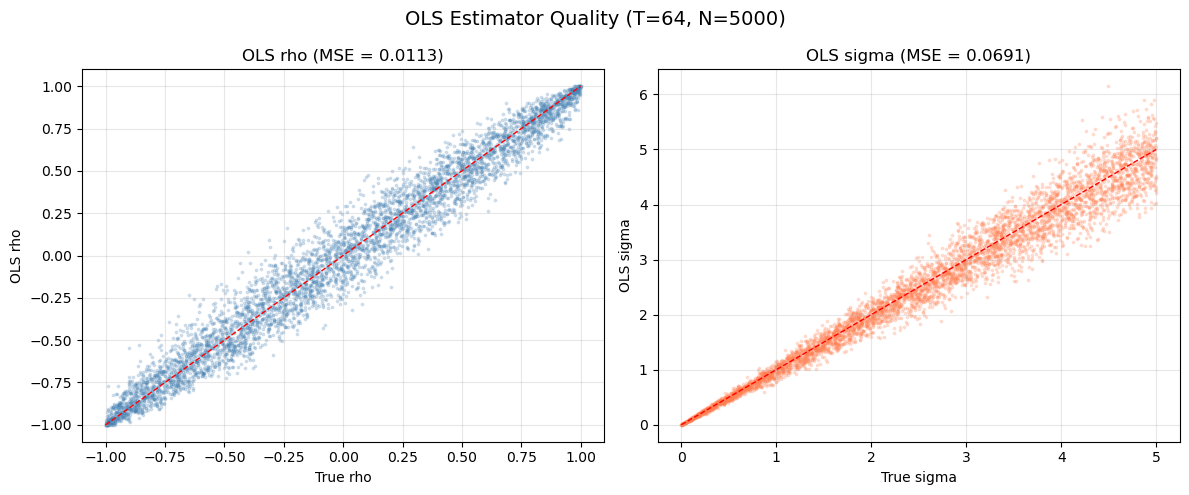

OLS MSE: rho=0.011309, sigma=0.069054, total=0.080363


In [5]:
# Evaluate OLS quality on a test sample
set_seed(0)
n_test = 5000
rho_test_ols = torch.empty(n_test).uniform_(-1, 1)
sigma_test_ols = torch.empty(n_test).uniform_(0, A)
x_test_ols = simulate_ar1_batch(rho_test_ols, sigma_test_ols, T, n_test)

ols_est = compute_ols_batch(x_test_ols)
ols_rho = ols_est[:, 0].numpy()
ols_sigma = ols_est[:, 1].numpy()
rho_true = rho_test_ols.numpy()
sigma_true = sigma_test_ols.numpy()

mse_ols_rho = np.mean((rho_true - ols_rho)**2)
mse_ols_sigma = np.mean((sigma_true - ols_sigma)**2)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(rho_true, ols_rho, alpha=0.2, s=3, color='steelblue')
axes[0].plot([-1, 1], [-1, 1], 'r--', linewidth=1)
axes[0].set_xlabel('True rho'); axes[0].set_ylabel('OLS rho')
axes[0].set_title(f'OLS rho (MSE = {mse_ols_rho:.4f})')
axes[0].grid(True, alpha=0.3)

axes[1].scatter(sigma_true, ols_sigma, alpha=0.2, s=3, color='coral')
axes[1].plot([0, A], [0, A], 'r--', linewidth=1)
axes[1].set_xlabel('True sigma'); axes[1].set_ylabel('OLS sigma')
axes[1].set_title(f'OLS sigma (MSE = {mse_ols_sigma:.4f})')
axes[1].grid(True, alpha=0.3)

plt.suptitle(f'OLS Estimator Quality (T={T}, N={n_test})', fontsize=14)
plt.tight_layout(); plt.show()

print(f"OLS MSE: rho={mse_ols_rho:.6f}, sigma={mse_ols_sigma:.6f}, total={mse_ols_rho+mse_ols_sigma:.6f}")

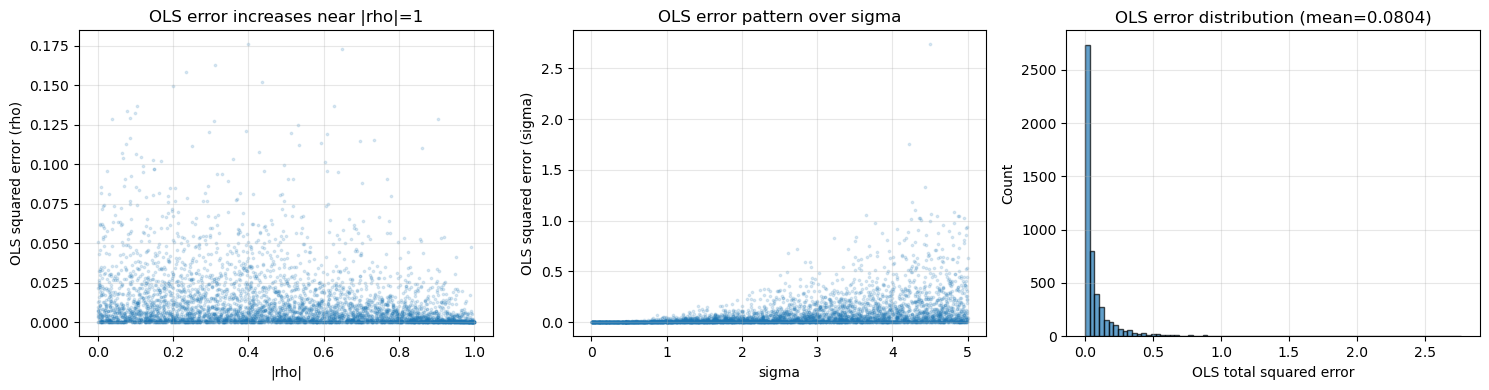

OLS struggles in the same regions as neural networks (high |rho|, extreme sigma)
=> OLS loss is a good control variate for NN loss (high correlation expected)


In [6]:
# Correlation analysis: OLS errors vs parameter regions
ols_err_rho = (ols_rho - rho_true)**2
ols_err_sigma = (ols_sigma - sigma_true)**2
ols_err_total = ols_err_rho + ols_err_sigma

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Error vs |rho|
axes[0].scatter(np.abs(rho_true), ols_err_rho, alpha=0.15, s=3)
axes[0].set_xlabel('|rho|'); axes[0].set_ylabel('OLS squared error (rho)')
axes[0].set_title('OLS error increases near |rho|=1')
axes[0].grid(True, alpha=0.3)

# Error vs sigma
axes[1].scatter(sigma_true, ols_err_sigma, alpha=0.15, s=3)
axes[1].set_xlabel('sigma'); axes[1].set_ylabel('OLS squared error (sigma)')
axes[1].set_title('OLS error pattern over sigma')
axes[1].grid(True, alpha=0.3)

# OLS error distribution
axes[2].hist(ols_err_total, bins=80, alpha=0.7, edgecolor='black')
axes[2].set_xlabel('OLS total squared error'); axes[2].set_ylabel('Count')
axes[2].set_title(f'OLS error distribution (mean={ols_err_total.mean():.4f})')
axes[2].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

# Key insight: OLS and NN errors are spatially correlated
print("OLS struggles in the same regions as neural networks (high |rho|, extreme sigma)")
print("=> OLS loss is a good control variate for NN loss (high correlation expected)")

## D. Input Augmentation Architecture

Instead of the neural network learning to map raw time series $x \to (\rho, \sigma)$ from scratch, we provide the OLS estimates as **additional input features**:

$$\text{Standard: } f_\phi(x) \to (\hat\rho, \hat\sigma)$$
$$\text{Augmented: } f_\phi\bigl(x,\; \hat\rho_{\text{OLS}},\; \hat\sigma_{\text{OLS}}\bigr) \to (\hat\rho, \hat\sigma)$$

Architecture:
```
Standard:   x -> GRU -> mean_pool -> MLP(64 -> 128 -> 128 -> 32 -> 2)
Augmented:  x -> GRU -> mean_pool --+
            x -> OLS estimates -----+--> concat --> MLP(66 -> 128 -> 128 -> 32 -> 2)
```

The augmented model can learn to **refine** the OLS estimate using the full time series information, rather than building the entire mapping from scratch. This is conceptually related to control variates: the OLS estimate captures the "predictable" part, and the network focuses on the residual.

In [7]:
def train_model(alpha_rho, alpha_sigma, beta_sigma, n_epochs, n_batches,
                batch_size, device, seed=None, use_augmentation=False):
    """Train one GRU model. Returns (model, train_losses, test_losses, ess_history)."""
    if seed is not None:
        set_seed(seed)

    if use_augmentation:
        model = AugmentedGRUPosteriorEstimator(
            input_dim=1, hidden_dim=64, num_layers=2, mlp_hidden=128, aug_dim=2
        ).to(device)
    else:
        model = GRUPosteriorEstimator(
            input_dim=1, hidden_dim=64, num_layers=2, mlp_hidden=128
        ).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=0.002)
    train_losses, test_losses, ess_history = [], [], []

    # Internal validation set (fixed seed, restored after)
    np_state = np.random.get_state()
    torch_state = torch.random.get_rng_state()
    cuda_state = torch.cuda.get_rng_state() if torch.cuda.is_available() else None
    set_seed(99999)
    rho_test = torch.empty(1024, device=device).uniform_(-1, 1)
    sigma_test = torch.empty(1024, device=device).uniform_(0, A)
    x_test = simulate_ar1_batch(rho_test, sigma_test, T, 1024, device=device)
    ols_test = compute_ols_batch(x_test).detach()
    np.random.set_state(np_state)
    torch.random.set_rng_state(torch_state)
    if cuda_state is not None:
        torch.cuda.set_rng_state(cuda_state)

    for epoch in range(n_epochs):
        model.train()
        epoch_loss = 0.0
        epoch_ess = 0.0

        for _ in range(n_batches):
            rho, sigma = sample_from_proposal(
                batch_size, alpha_rho, alpha_sigma, beta_sigma, A, device=device)
            weights = compute_importance_weights(
                rho, sigma, alpha_rho, alpha_sigma, beta_sigma, A)
            weights = torch.tensor(weights, dtype=torch.float32, device=device)
            weights = torch.nan_to_num(weights, nan=1.0, posinf=10.0, neginf=0.1)
            weights = torch.clamp(weights, min=0.1, max=10.0)
            w_norm = weights / weights.sum()
            epoch_ess += 1.0 / (w_norm**2).sum().item()

            x = simulate_ar1_batch(rho, sigma, T, batch_size, device=device)
            if torch.isnan(x).any() or torch.isinf(x).any():
                continue

            ols_feat = compute_ols_batch(x).detach() if use_augmentation else None
            theta_pred = model(x, ols_features=ols_feat)
            if torch.isnan(theta_pred).any() or torch.isinf(theta_pred).any():
                continue

            loss_per_sample = ((theta_pred - torch.stack([rho, sigma], dim=1))**2).sum(dim=1)
            loss = torch.sum(w_norm * loss_per_sample)
            if torch.isnan(loss) or torch.isinf(loss):
                continue

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            epoch_loss += loss.item()

        train_losses.append(epoch_loss / n_batches)
        ess_history.append(epoch_ess / n_batches)

        model.eval()
        with torch.no_grad():
            pred_test = model(x_test, ols_features=ols_test if use_augmentation else None)
            tl = ((pred_test - torch.stack([rho_test, sigma_test], dim=1))**2).mean().item()
            test_losses.append(tl)

    return model, train_losses, test_losses, ess_history

print("train_model() defined (supports standard and augmented modes)")

train_model() defined (supports standard and augmented modes)


## E. Shared Test Set & Gibbs Baseline

In [8]:
# Generate shared uniform test set
set_seed(0)
rho_eval = torch.empty(N_EVAL, device='cpu').uniform_(-1, 1)
sigma_eval = torch.empty(N_EVAL, device='cpu').uniform_(0, A)
x_eval = simulate_ar1_batch(rho_eval, sigma_eval, T, N_EVAL, device='cpu')

rho_eval_np = rho_eval.numpy()
sigma_eval_np = sigma_eval.numpy()
x_eval_np = x_eval.numpy()

# OLS estimates on the test set
ols_eval = compute_ols_batch(x_eval)
ols_eval_np = ols_eval.numpy()

mse_ols_rho_eval = np.mean((rho_eval_np - ols_eval_np[:, 0])**2)
mse_ols_sigma_eval = np.mean((sigma_eval_np - ols_eval_np[:, 1])**2)

print(f"Shared test set: {N_EVAL} samples (seed=0)")
print(f"OLS baseline on test set: rho MSE={mse_ols_rho_eval:.6f}, sigma MSE={mse_ols_sigma_eval:.6f}, "
      f"total={mse_ols_rho_eval + mse_ols_sigma_eval:.6f}")

Shared test set: 10000 samples (seed=0)
OLS baseline on test set: rho MSE=0.010933, sigma MSE=0.066248, total=0.077181


In [9]:
# Gibbs sampler baseline
print("Running Gibbs sampler on shared test set...")
set_seed(1)

rho_gibbs = np.zeros(N_EVAL)
sigma_gibbs = np.zeros(N_EVAL)

for i in tqdm(range(N_EVAL)):
    samples = gibbs(x_eval_np[i], n_iter=1000)
    rho_gibbs[i] = np.mean(samples[:, 0])
    sigma_gibbs[i] = np.mean(samples[:, 1])

mse_rho_gibbs = np.mean((rho_eval_np - rho_gibbs)**2)
mse_sigma_gibbs = np.mean((sigma_eval_np - sigma_gibbs)**2)
total_gibbs = mse_rho_gibbs + mse_sigma_gibbs
print(f"Gibbs MSE: rho={mse_rho_gibbs:.6f}, sigma={mse_sigma_gibbs:.6f}, total={total_gibbs:.6f}")

Running Gibbs sampler on shared test set...


100%|██████████| 10000/10000 [01:23<00:00, 119.63it/s]

Gibbs MSE: rho=0.010922, sigma=0.053989, total=0.064911


## F. Multi-Run Training (2 methods x 4 alphas x 3 runs = 24 models)

In [ ]:
# Main training loop
all_models = {}
all_train_losses = {}
all_test_losses = {}
all_ess_histories = {}
training_times = {}

for method in METHODS:
    use_aug = (method == 'augmented')
    all_models[method] = {}
    all_train_losses[method] = {}
    all_test_losses[method] = {}
    all_ess_histories[method] = {}
    training_times[method] = {}

    for ai, alpha in enumerate(ALPHA_VALUES):
        all_models[method][alpha] = {}
        all_train_losses[method][alpha] = {}
        all_test_losses[method][alpha] = {}
        all_ess_histories[method][alpha] = {}
        training_times[method][alpha] = {}

        print(f"\n{'='*80}")
        print(f"Method={method.upper()}, ALPHA={alpha}  ({R} runs)")
        print(f"{'='*80}")

        for run in range(R):
            # Same seeds for both methods so the only difference is architecture
            seed = BASE_SEED + ai * 100 + run
            print(f"  Run {run+1}/{R} (seed={seed})... ", end="", flush=True)

            t0 = time.time()
            model, trl, tel, essh = train_model(
                alpha_rho=alpha, alpha_sigma=alpha, beta_sigma=BETA_SIGMA,
                n_epochs=N_EPOCHS, n_batches=N_BATCHES_PER_EPOCH,
                batch_size=TRAINING_BATCH_SIZE, device=device,
                seed=seed, use_augmentation=use_aug)
            elapsed = time.time() - t0

            all_models[method][alpha][run] = model
            all_train_losses[method][alpha][run] = trl
            all_test_losses[method][alpha][run] = tel
            all_ess_histories[method][alpha][run] = essh
            training_times[method][alpha][run] = elapsed

            print(f"done in {elapsed:.1f}s  (final test loss: {tel[-1]:.4f})")

total_time = sum(t for m in training_times for a in training_times[m]
                 for t in training_times[m][a].values())
print(f"\n{'='*80}")
print(f"All {len(METHODS)*len(ALPHA_VALUES)*R} models trained in {total_time/60:.1f} minutes")
print(f"{'='*80}")


Method=STANDARD, ALPHA=1.0  (3 runs)
  Run 1/3 (seed=42)... done in 337.9s  (final test loss: 0.0519)
  Run 2/3 (seed=43)... done in 342.3s  (final test loss: 0.0484)
  Run 3/3 (seed=44)... done in 384.8s  (final test loss: 0.0474)

Method=STANDARD, ALPHA=0.5  (3 runs)
  Run 1/3 (seed=142)... done in 621.8s  (final test loss: 0.0797)
  Run 2/3 (seed=143)... 

In [ ]:
# Collect predictions on shared test set
all_predictions = {}  # [method][alpha][run] = (N, 2)
x_eval_gpu = x_eval.to(device)
ols_eval_gpu = ols_eval.to(device)

for method in METHODS:
    all_predictions[method] = {}
    use_aug = (method == 'augmented')
    for alpha in ALPHA_VALUES:
        all_predictions[method][alpha] = {}
        for run in range(R):
            all_models[method][alpha][run].eval()
            with torch.no_grad():
                ols_feat = ols_eval_gpu if use_aug else None
                pred = all_models[method][alpha][run](x_eval_gpu, ols_features=ols_feat).cpu().numpy()
                all_predictions[method][alpha][run] = pred

# Mean predictions across runs
mean_preds = {}
for method in METHODS:
    mean_preds[method] = {}
    for alpha in ALPHA_VALUES:
        stacked = np.stack([all_predictions[method][alpha][r] for r in range(R)], axis=0)
        mean_preds[method][alpha] = stacked.mean(axis=0)

print(f"Predictions collected: {len(METHODS)} methods x {len(ALPHA_VALUES)} alphas x {R} runs")

## G. Training Convergence

In [ ]:
# Confidence band plots: standard vs augmented
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
colors_method = {'standard': 'steelblue', 'augmented': 'coral'}
epochs = np.arange(N_EPOCHS)

for ai, alpha in enumerate(ALPHA_VALUES):
    row, col = ai // 2, ai % 2
    ax = axes[row, col]
    for method in METHODS:
        test_arr = np.array([all_test_losses[method][alpha][r] for r in range(R)])
        mu, sd = test_arr.mean(axis=0), test_arr.std(axis=0)
        c = colors_method[method]
        ax.plot(epochs, mu, color=c, label=f'{method}')
        ax.fill_between(epochs, mu - sd, mu + sd, color=c, alpha=0.15)

    ax.set_xlabel('Epoch'); ax.set_ylabel('Test MSE')
    ax.set_title(f'alpha={alpha}'); ax.legend(); ax.grid(True, alpha=0.3)

plt.suptitle('Test Loss Convergence: Standard vs Augmented (mean +/- std)', fontsize=14)
plt.tight_layout(); plt.show()

In [ ]:
# Per-run final test loss table
print("\n" + "="*90)
print("FINAL TEST LOSS PER RUN")
print("="*90)

for method in METHODS:
    print(f"\n--- {method.upper()} ---")
    header = f"{'Alpha':<10}" + "".join(f"{'Run '+str(r+1):<12}" for r in range(R)) + f"{'Mean':<12}{'Std':<12}"
    print(header)
    print("-"*70)
    for alpha in ALPHA_VALUES:
        losses = [all_test_losses[method][alpha][r][-1] for r in range(R)]
        row = f"{'a='+str(alpha):<10}" + "".join(f"{l:<12.4f}" for l in losses)
        row += f"{np.mean(losses):<12.4f}{np.std(losses):<12.4f}"
        print(row)

print("="*90)

## H. Control Variate-Adjusted Evaluation

We now apply the control variate to **evaluation**. For each test point $i$:

$$e_i^{\text{NN}} = \|\hat\theta_{\text{NN}}(x_i) - \theta_i\|^2, \qquad e_i^{\text{OLS}} = \|\hat\theta_{\text{OLS}}(x_i) - \theta_i\|^2$$

The CV-adjusted estimator of $\mathbb{E}[e^{\text{NN}}]$ (the MSE) is:

$$\widehat{\text{MSE}}_{\text{CV}} = \bar{e}^{\text{NN}} - c^*\,(\bar{e}^{\text{OLS}} - \mu_{\text{OLS}})$$

where $c^* = \text{Cov}(e^{\text{NN}}, e^{\text{OLS}})/\text{Var}(e^{\text{OLS}})$.

This doesn't change the MSE itself -- it gives us a **tighter estimate** of the MSE, reducing the confidence interval width.

In [ ]:
# CV-adjusted evaluation: demonstrate variance reduction
# Use bootstrap to show the CI width with vs without CV
N_BOOT = 2000
boot_size = 1000  # subsample size for bootstrap

print("="*90)
print("CONTROL VARIATE FOR EVALUATION: VARIANCE REDUCTION")
print("="*90)

ols_losses = (ols_eval_np[:, 0] - rho_eval_np)**2 + (ols_eval_np[:, 1] - sigma_eval_np)**2
mu_ols = ols_losses.mean()

fig, axes = plt.subplots(2, len(ALPHA_VALUES), figsize=(4*len(ALPHA_VALUES), 8))

for ai, alpha in enumerate(ALPHA_VALUES):
    for mi, method in enumerate(METHODS):
        pm = mean_preds[method][alpha]
        nn_losses = (pm[:, 0] - rho_eval_np)**2 + (pm[:, 1] - sigma_eval_np)**2

        # Correlation
        corr = np.corrcoef(nn_losses, ols_losses)[0, 1]

        # Bootstrap: raw vs CV-adjusted
        raw_boots = np.zeros(N_BOOT)
        cv_boots = np.zeros(N_BOOT)
        rng = np.random.RandomState(42)
        for b in range(N_BOOT):
            idx = rng.choice(N_EVAL, boot_size, replace=True)
            nn_sub = nn_losses[idx]
            ols_sub = ols_losses[idx]

            raw_boots[b] = nn_sub.mean()

            c_star = np.cov(nn_sub, ols_sub)[0, 1] / (np.var(ols_sub) + 1e-12)
            cv_boots[b] = nn_sub.mean() - c_star * (ols_sub.mean() - mu_ols)

        var_reduction = 1 - cv_boots.var() / raw_boots.var()

        ax = axes[mi, ai]
        ax.hist(raw_boots, bins=40, alpha=0.5, label=f'Raw (std={raw_boots.std():.4f})',
                edgecolor='black', color='steelblue')
        ax.hist(cv_boots, bins=40, alpha=0.5, label=f'CV  (std={cv_boots.std():.4f})',
                edgecolor='black', color='coral')
        ax.set_title(f'{method}, a={alpha}\nrho={corr:.2f}, VR={var_reduction:.1%}')
        ax.legend(fontsize=7)
        ax.set_xlabel('MSE estimate')

        if ai == 0:
            print(f"\n{method.upper()}, alpha={alpha}: corr(NN,OLS)={corr:.3f}, variance reduction={var_reduction:.1%}")
        else:
            print(f"{method.upper()}, alpha={alpha}: corr(NN,OLS)={corr:.3f}, variance reduction={var_reduction:.1%}")

plt.suptitle('Bootstrap MSE Estimates: Raw vs CV-Adjusted', fontsize=14)
plt.tight_layout(); plt.show()
print("="*90)

## I. Aggregate Performance

In [ ]:
# Comprehensive metrics table
print("\n" + "="*110)
print(f"AGGREGATE PERFORMANCE (mean +/- std across R={R} runs)")
print("="*110)
print(f"{'Method':<12} {'Alpha':<8} {'MSE(rho)':<20} {'MSE(sigma)':<20} {'Total MSE':<20}")
print("-"*80)

# Gibbs and OLS baselines
total_ols = mse_ols_rho_eval + mse_ols_sigma_eval
print(f"{'Gibbs':<12} {'--':<8} {mse_rho_gibbs:<20.6f} {mse_sigma_gibbs:<20.6f} {total_gibbs:<20.6f}")
print(f"{'OLS':<12} {'--':<8} {mse_ols_rho_eval:<20.6f} {mse_ols_sigma_eval:<20.6f} {total_ols:<20.6f}")
print("-"*80)

run_metrics = {}
for method in METHODS:
    run_metrics[method] = {}
    for alpha in ALPHA_VALUES:
        mse_rho_runs, mse_sigma_runs, total_runs = [], [], []
        for r in range(R):
            pred = all_predictions[method][alpha][r]
            mr = np.mean((rho_eval_np - pred[:, 0])**2)
            ms = np.mean((sigma_eval_np - pred[:, 1])**2)
            mse_rho_runs.append(mr); mse_sigma_runs.append(ms)
            total_runs.append(mr + ms)
        run_metrics[method][alpha] = dict(
            mse_rho=mse_rho_runs, mse_sigma=mse_sigma_runs, total=total_runs)

        fmt = lambda v: f"{np.mean(v):.4f}+/-{np.std(v):.4f}"
        print(f"{method:<12} {'a='+str(alpha):<8} {fmt(mse_rho_runs):<20} "
              f"{fmt(mse_sigma_runs):<20} {fmt(total_runs):<20}")
print("="*110)

In [ ]:
# Box plots: standard vs augmented
fig, axes = plt.subplots(1, len(ALPHA_VALUES), figsize=(4*len(ALPHA_VALUES), 5))

for ai, alpha in enumerate(ALPHA_VALUES):
    data = [run_metrics[m][alpha]['total'] for m in METHODS]
    bp = axes[ai].boxplot(data, labels=['Std', 'Aug'], patch_artist=True)
    bp['boxes'][0].set_facecolor('steelblue'); bp['boxes'][0].set_alpha(0.5)
    bp['boxes'][1].set_facecolor('coral'); bp['boxes'][1].set_alpha(0.5)
    for mi, method in enumerate(METHODS):
        axes[ai].scatter([mi+1]*R, run_metrics[method][alpha]['total'],
                        color=['steelblue', 'coral'][mi], zorder=5, s=50)

    axes[ai].axhline(y=total_gibbs, color='green', linestyle='--', label='Gibbs')
    axes[ai].axhline(y=total_ols, color='gray', linestyle=':', label='OLS')
    axes[ai].set_ylabel('Total MSE'); axes[ai].set_title(f'alpha={alpha}')
    axes[ai].legend(fontsize=7); axes[ai].grid(True, alpha=0.3)

plt.suptitle('Total MSE: Standard vs Augmented (per run)', fontsize=14)
plt.tight_layout(); plt.show()

In [ ]:
# Statistical tests: standard vs augmented (paired t-test on per-sample errors)
print("\n" + "="*80)
print("STATISTICAL TESTS: Standard vs Augmented")
print("Paired t-test on per-sample squared errors (N={})".format(N_EVAL))
print("="*80)

for alpha in ALPHA_VALUES:
    err_std = (mean_preds['standard'][alpha][:, 0] - rho_eval_np)**2 + \
              (mean_preds['standard'][alpha][:, 1] - sigma_eval_np)**2
    err_aug = (mean_preds['augmented'][alpha][:, 0] - rho_eval_np)**2 + \
              (mean_preds['augmented'][alpha][:, 1] - sigma_eval_np)**2

    t_stat, p_val = ttest_rel(err_std, err_aug)
    mean_diff = np.mean(err_std - err_aug)

    print(f"\nalpha={alpha}:")
    print(f"  Mean MSE diff (standard - augmented): {mean_diff:+.6f}")
    print(f"  t-statistic: {t_stat:.4f}, p-value: {p_val:.6e}")
    if p_val < 0.05:
        winner = "Standard" if mean_diff < 0 else "Augmented"
        print(f"  Significant at 5%: {winner} is better")
    else:
        print(f"  Not significant at 5%")

print("="*80)

## J. Bias-Variance Decomposition

$$\text{MSE}_i = \underbrace{(\bar{\hat\theta}_i - \theta_i)^2}_{\text{Bias}^2} + \underbrace{\frac{1}{R}\sum_{r=1}^{R} (\hat\theta_i^{(r)} - \bar{\hat\theta}_i)^2}_{\text{Variance}}$$

If input augmentation helps, we expect it to reduce **bias** (better point predictions on average) and/or **variance** (more consistent across training runs).

In [ ]:
# Bias-variance decomposition: standard vs augmented
print("\n" + "="*110)
print("BIAS-VARIANCE DECOMPOSITION")
print("="*110)

bv_results = {}
true_vals = np.stack([rho_eval_np, sigma_eval_np], axis=1)

for method in METHODS:
    bv_results[method] = {}
    for alpha in ALPHA_VALUES:
        preds = np.stack([all_predictions[method][alpha][r] for r in range(R)], axis=0)
        mean_pred = preds.mean(axis=0)
        bias_sq = (mean_pred - true_vals)**2
        variance = np.mean((preds - mean_pred[None, :, :])**2, axis=0)
        mse_decomp = bias_sq + variance

        bv_results[method][alpha] = dict(
            bias_sq_rho=bias_sq[:, 0].mean(), bias_sq_sigma=bias_sq[:, 1].mean(),
            var_rho=variance[:, 0].mean(), var_sigma=variance[:, 1].mean(),
            mse_rho=mse_decomp[:, 0].mean(), mse_sigma=mse_decomp[:, 1].mean(),
            bias_sq=bias_sq, variance=variance, mse=mse_decomp)

print(f"{'Method':<12} {'Alpha':<8} {'Bias2(rho)':<12} {'Var(rho)':<12} {'Bias2(sig)':<12} "
      f"{'Var(sig)':<12} {'Total MSE':<12}")
print("-"*80)
for method in METHODS:
    for alpha in ALPHA_VALUES:
        bv = bv_results[method][alpha]
        total = bv['mse_rho'] + bv['mse_sigma']
        print(f"{method:<12} {'a='+str(alpha):<8} {bv['bias_sq_rho']:<12.6f} {bv['var_rho']:<12.6f} "
              f"{bv['bias_sq_sigma']:<12.6f} {bv['var_sigma']:<12.6f} {total:<12.6f}")

# Stacked bar chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
x_pos = np.arange(len(ALPHA_VALUES))
width = 0.35

for col, param in enumerate(['rho', 'sigma']):
    for mi, method in enumerate(METHODS):
        offset = -width/2 + mi * width
        b2 = [bv_results[method][a][f'bias_sq_{param}'] for a in ALPHA_VALUES]
        va = [bv_results[method][a][f'var_{param}'] for a in ALPHA_VALUES]
        c1, c2 = ('steelblue', 'lightblue') if method == 'standard' else ('coral', 'lightsalmon')
        axes[col].bar(x_pos + offset, b2, width, label=f'{method} Bias^2', color=c1)
        axes[col].bar(x_pos + offset, va, width, bottom=b2, label=f'{method} Var', color=c2)

    axes[col].set_xticks(x_pos)
    axes[col].set_xticklabels([f'a={a}' for a in ALPHA_VALUES])
    axes[col].set_ylabel('MSE'); axes[col].set_title(f'Bias^2-Variance: {param}')
    axes[col].legend(fontsize=7); axes[col].grid(True, alpha=0.3, axis='y')

plt.suptitle('Bias^2-Variance Decomposition: Standard vs Augmented', fontsize=14)
plt.tight_layout(); plt.show()
print("="*110)

In [ ]:
# Spatial difference heatmaps: Augmented - Standard MSE
N_BINS = 20
rho_edges = np.linspace(-1, 1, N_BINS + 1)
sigma_edges = np.linspace(0, A, N_BINS + 1)
rho_bin_idx = np.clip(np.digitize(rho_eval_np, rho_edges) - 1, 0, N_BINS - 1)
sigma_bin_idx = np.clip(np.digitize(sigma_eval_np, sigma_edges) - 1, 0, N_BINS - 1)

fig, axes = plt.subplots(1, len(ALPHA_VALUES), figsize=(5*len(ALPHA_VALUES), 4))

for ai, alpha in enumerate(ALPHA_VALUES):
    std_total = bv_results['standard'][alpha]['mse'][:, 0] + bv_results['standard'][alpha]['mse'][:, 1]
    aug_total = bv_results['augmented'][alpha]['mse'][:, 0] + bv_results['augmented'][alpha]['mse'][:, 1]

    diff_grid = np.full((N_BINS, N_BINS), np.nan)
    for ri in range(N_BINS):
        for si in range(N_BINS):
            mask = (rho_bin_idx == ri) & (sigma_bin_idx == si)
            if mask.sum() > 0:
                diff_grid[si, ri] = np.mean(aug_total[mask]) - np.mean(std_total[mask])

    vmax = np.nanmax(np.abs(diff_grid))
    im = axes[ai].imshow(diff_grid, origin='lower', aspect='auto',
                         extent=[-1, 1, 0, A], cmap='RdBu_r', vmin=-vmax, vmax=vmax)
    plt.colorbar(im, ax=axes[ai])
    axes[ai].set_xlabel('rho'); axes[ai].set_ylabel('sigma')
    axes[ai].set_title(f'a={alpha}\nBlue=Aug better, Red=Std better')

plt.suptitle('MSE Difference: Augmented - Standard (spatial)', fontsize=14)
plt.tight_layout(); plt.show()

## K. Regional / Boundary Performance

| Region | Definition |
|--------|-----------|
| Interior | $|\rho| < 0.8$ and $0.5 < \sigma < 4$ |
| High $|\rho|$ | $|\rho| > 0.95$ |
| Low $\sigma$ | $\sigma < 0.2$ |
| High $\sigma$ | $\sigma > 4.0$ |

In [ ]:
# Regional MSE table
regions = {
    'Interior': (np.abs(rho_eval_np) < 0.8) & (sigma_eval_np > 0.5) & (sigma_eval_np < 4.0),
    'High |rho|': np.abs(rho_eval_np) > 0.95,
    'Low sigma': sigma_eval_np < 0.2,
    'High sigma': sigma_eval_np > 4.0,
}

print("\n" + "="*90)
print(f"REGIONAL MSE (mean +/- std across R={R} runs)")
print("="*90)

regional_metrics = {}
for region_name, mask in regions.items():
    n_s = mask.sum()
    print(f"\n{region_name} ({n_s} samples)")
    print(f"{'Method':<12} {'Alpha':<8} {'Total MSE':<22}")
    print("-"*42)

    g_rho = np.mean((rho_eval_np[mask] - rho_gibbs[mask])**2)
    g_sig = np.mean((sigma_eval_np[mask] - sigma_gibbs[mask])**2)
    print(f"{'Gibbs':<12} {'--':<8} {g_rho+g_sig:<22.6f}")

    o_rho = np.mean((rho_eval_np[mask] - ols_eval_np[mask, 0])**2)
    o_sig = np.mean((sigma_eval_np[mask] - ols_eval_np[mask, 1])**2)
    print(f"{'OLS':<12} {'--':<8} {o_rho+o_sig:<22.6f}")

    regional_metrics[region_name] = {}
    for method in METHODS:
        regional_metrics[region_name][method] = {}
        for alpha in ALPHA_VALUES:
            totals = []
            for r in range(R):
                pred = all_predictions[method][alpha][r]
                mr = np.mean((rho_eval_np[mask] - pred[mask, 0])**2)
                ms = np.mean((sigma_eval_np[mask] - pred[mask, 1])**2)
                totals.append(mr + ms)
            regional_metrics[region_name][method][alpha] = totals
            fmt = lambda v: f"{np.mean(v):.4f}+/-{np.std(v):.4f}"
            print(f"{method:<12} {'a='+str(alpha):<8} {fmt(totals):<22}")

print("="*90)

In [ ]:
# Regional box plots: standard vs augmented at alpha=1.0 and best IS alpha
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes_flat = axes.flatten()

for idx, (region_name, mask) in enumerate(regions.items()):
    ax = axes_flat[idx]
    labels, data, clrs = [], [], []
    for method in METHODS:
        for alpha in [1.0, 0.3]:  # uniform + moderate IS
            labels.append(f'{method[:3]}\na={alpha}')
            data.append(regional_metrics[region_name][method][alpha])
            clrs.append('steelblue' if method == 'standard' else 'coral')

    bp = ax.boxplot(data, labels=labels, patch_artist=True)
    for patch, c in zip(bp['boxes'], clrs):
        patch.set_facecolor(c); patch.set_alpha(0.5)
    for i in range(len(data)):
        ax.scatter([i+1]*R, data[i], color=clrs[i], zorder=5, s=40)

    g_rho = np.mean((rho_eval_np[mask] - rho_gibbs[mask])**2)
    g_sig = np.mean((sigma_eval_np[mask] - sigma_gibbs[mask])**2)
    ax.axhline(y=g_rho + g_sig, color='green', linestyle='--', label='Gibbs')
    ax.set_ylabel('Total MSE')
    ax.set_title(f'{region_name} ({mask.sum()} samples)')
    ax.legend(fontsize=7); ax.grid(True, alpha=0.3)

plt.suptitle('Regional MSE: Standard vs Augmented', fontsize=14)
plt.tight_layout(); plt.show()

## L. Prediction Quality

In [ ]:
# True vs Predicted scatter: standard vs augmented at alpha=1.0
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for mi, method in enumerate(METHODS):
    pm = mean_preds[method][1.0]
    axes[0, mi].scatter(rho_eval_np, rho_gibbs, alpha=0.12, s=2, label='Gibbs', color='green')
    axes[0, mi].scatter(rho_eval_np, pm[:, 0], alpha=0.15, s=3, label=f'GRU ({method})', color='steelblue' if mi==0 else 'coral')
    axes[0, mi].plot([-1, 1], [-1, 1], 'r--', linewidth=1)
    axes[0, mi].set_xlabel('True rho'); axes[0, mi].set_ylabel('Est. rho')
    axes[0, mi].set_title(f'{method}, alpha=1.0 (rho)')
    axes[0, mi].set_xlim([-1, 1]); axes[0, mi].set_ylim([-1, 1])
    axes[0, mi].legend(fontsize=7); axes[0, mi].grid(True, alpha=0.3)

    axes[1, mi].scatter(sigma_eval_np, sigma_gibbs, alpha=0.12, s=2, label='Gibbs', color='green')
    axes[1, mi].scatter(sigma_eval_np, pm[:, 1], alpha=0.15, s=3, label=f'GRU ({method})', color='steelblue' if mi==0 else 'coral')
    axes[1, mi].plot([0, A], [0, A], 'r--', linewidth=1)
    axes[1, mi].set_xlabel('True sigma'); axes[1, mi].set_ylabel('Est. sigma')
    axes[1, mi].set_title(f'{method}, alpha=1.0 (sigma)')
    axes[1, mi].set_xlim([0, A]); axes[1, mi].set_ylim([0, A])
    axes[1, mi].legend(fontsize=7); axes[1, mi].grid(True, alpha=0.3)

plt.suptitle('True vs Predicted (mean across runs, alpha=1.0)', fontsize=14)
plt.tight_layout(); plt.show()

In [ ]:
# Error distributions for all alphas: standard vs augmented
fig, axes = plt.subplots(2, len(ALPHA_VALUES), figsize=(4*len(ALPHA_VALUES), 8))

for ai, alpha in enumerate(ALPHA_VALUES):
    for mi, method in enumerate(METHODS):
        pm = mean_preds[method][alpha]
        rho_err = pm[:, 0] - rho_eval_np
        sig_err = pm[:, 1] - sigma_eval_np
        c = 'steelblue' if method == 'standard' else 'coral'

        axes[0, ai].hist(rho_err, bins=50, alpha=0.5, edgecolor='black', color=c,
                         label=f'{method[:3]} (std={np.std(rho_err):.3f})')
        axes[1, ai].hist(sig_err, bins=50, alpha=0.5, edgecolor='black', color=c,
                         label=f'{method[:3]} (std={np.std(sig_err):.3f})')

    axes[0, ai].axvline(x=0, color='r', linestyle='--')
    axes[0, ai].set_xlabel('Error (rho)'); axes[0, ai].set_title(f'a={alpha}')
    axes[0, ai].legend(fontsize=7)
    axes[1, ai].axvline(x=0, color='r', linestyle='--')
    axes[1, ai].set_xlabel('Error (sigma)'); axes[1, ai].set_title(f'a={alpha}')
    axes[1, ai].legend(fontsize=7)

axes[0, 0].set_ylabel('Count'); axes[1, 0].set_ylabel('Count')
plt.suptitle('Error Distributions: Standard vs Augmented', fontsize=14)
plt.tight_layout(); plt.show()

In [ ]:
# Worst-case analysis
print("\n" + "="*80)
print("WORST CASE ANALYSIS (mean predictions)")
print("="*80)

for method in METHODS:
    pm = mean_preds[method][1.0]
    total_errors = (pm[:, 0] - rho_eval_np)**2 + (pm[:, 1] - sigma_eval_np)**2
    worst_idx = np.argsort(total_errors)[-5:]

    print(f"\n{method.upper()} (alpha=1.0):")
    print(f"{'Idx':<8} {'True rho':<12} {'Pred rho':<12} {'True sig':<12} {'Pred sig':<12} {'Error':<12}")
    print("-"*68)
    for idx in reversed(worst_idx):
        print(f"{idx:<8} {rho_eval_np[idx]:<12.3f} {pm[idx, 0]:<12.3f} "
              f"{sigma_eval_np[idx]:<12.3f} {pm[idx, 1]:<12.3f} {total_errors[idx]:<12.4f}")

print("="*80)

## M. Summary

In [ ]:
# Experimental summary
print("\n" + "="*80)
print("EXPERIMENTAL SUMMARY")
print("="*80)

print(f"\nProtocol:")
print(f"  Methods: {METHODS}")
print(f"  Runs per condition: R = {R}")
print(f"  Alpha values: {ALPHA_VALUES}")
print(f"  Total models: {len(METHODS) * len(ALPHA_VALUES) * R}")
print(f"  Test set: N = {N_EVAL} (uniform, seed=0)")
print(f"  Training: {N_EPOCHS} epochs x {N_BATCHES_PER_EPOCH} batches x batch_size={TRAINING_BATCH_SIZE}")
print(f"  Total training time: {total_time/60:.1f} min")

print(f"\nBaselines:")
print(f"  Gibbs: {total_gibbs:.4f}")
print(f"  OLS:   {total_ols:.4f}")

print(f"\nGlobal ranking (Total MSE, mean +/- std):")
rankings = []
for method in METHODS:
    for alpha in ALPHA_VALUES:
        v = run_metrics[method][alpha]['total']
        rankings.append((method, alpha, np.mean(v), np.std(v)))
rankings.sort(key=lambda x: x[2])
for rank, (m, a, mu, sd) in enumerate(rankings, 1):
    print(f"  {rank}. {m} a={a}: {mu:.4f} +/- {sd:.4f}")

print(f"\nBias-Variance insight (alpha=1.0):")
for method in METHODS:
    bv = bv_results[method][1.0]
    tb = bv['bias_sq_rho'] + bv['bias_sq_sigma']
    tv = bv['var_rho'] + bv['var_sigma']
    tm = tb + tv
    print(f"  {method}: Bias^2={tb:.4f} ({100*tb/tm:.1f}%), Var={tv:.4f} ({100*tv/tm:.1f}%)")

print("\n" + "="*80)